# Assignment - A03 Update Frequency (30 ⭕️s)

**Jonah Ebent**


## Overview


In this assignment, you will compare three different ways to run gradient descent:

- **Batch** gradient descent (update once using the full dataset)
- **Stochastic** gradient descent (update once per data point)
- **Mini-batch** gradient descent (update once per small batch)

and analyze the differences between them.


### Dataset

This assignment uses the dataset `A03_housing_big.csv` from the Canvas assignment.

*If you are working in colab, you will need to upload this file to your colab session. If you are working in vscode, you need to have the csv file in the same directory as your notebook or point to it appropriately in the code below.*



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV dataset
df = pd.read_csv('A03_housing_big.csv')

# Convert columns to NumPy arrays
x_train = df['Size_1000sqft'].to_numpy()
y_train = df['Price_1000s'].to_numpy()

print(df.head())
print()
print(f"x_train.shape: {x_train.shape}")
print(f"y_train.shape: {y_train.shape}")


   Size_1000sqft  Price_1000s
0           0.55        220.4
1           0.55        197.2
2           0.55        194.3
3           0.55        208.5
4           0.55        191.9

x_train.shape: (6000,)
y_train.shape: (6000,)


## Plot the dataset

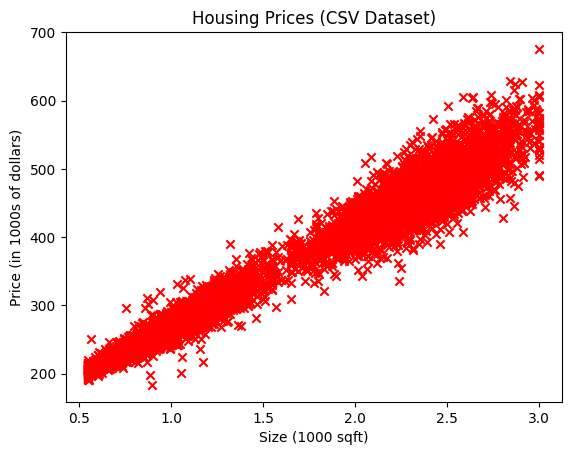

In [3]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title('Housing Prices (CSV Dataset)')
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()


## Start from your A02 & A03 Functions

Paste your working functions from A02 here:

- `compute_model_output(x, w, b)`
- `compute_cost(x, y, w, b)`
- `compute_gradient(x, y, w, b)`

If you have not used vectorized code in A02, **change your code to use vectorized versions** from the lecture notes.

⭕️

In [4]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      w,b (scalar)    : model parameters
    Returns
      f_wb (ndarray (m,)): model prediction
    """
    return w * x + b

def mean_squared_error(y, y_hat):
  assert len(y_hat) == len(y)
  m = len(y)
  return sum((y_hat - y) ** 2) / (2 * m)

def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      total_cost (scalar): the cost
    """
    assert(len(x) == len(y))
    y_hat = compute_model_output(x, w, b)
    return mean_squared_error(y, y_hat)

def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
    """
    assert(len(x) == len(y))
    m = len(x)
    residuals = compute_model_output(x, w, b) - y
    dj_dw = sum(residuals * x) / m
    dj_db = sum(residuals) / m
    return dj_dw, dj_db


### Task 1. Batch Gradient Descent
Batch gradient descent updates $w$ and $b$ once per iteration using **all m examples**.

Write a function:
- inputs: `x`, `y`, `w_in`, `b_in`, `alpha`, `num_iters`
- returns: `w`, `b`, `J_history`
- saves the cost value at each iteration.

You can start from your A02 gradient descent function and modify it if needed.

⭕️


In [5]:
# TODO: paste your A02 & A03 functions here and change to
#  vectorized versions if you have not done so already.

def batch_gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    """Batch gradient descent: update using the full dataset each iteration.
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations
    """
    assert len(x) == len(y)
    w, b = w_in, b_in
    J_history = []
    for _ in range(num_iters):
      cost = compute_cost(x, y, w, b)
      J_history.append(cost)
      dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)
      w -= alpha * dj_dw
      b -= alpha * dj_db
    return w, b, J_history


### Task 2. Stochastic Gradient Descent (SGD)
Stochastic gradient descent updates $w$ and $b$ once per **single training example**.

**IMPORTANT:** *For this task, do **NOT** shuffle the data yet.*

Write a function:
- inputs: `x`, `y`, `w_in`, `b_in`, `alpha`, `num_epochs`
- returns: `w`, `b`, `J_history`, `J_epoch_history`
- saves the cost value at the end of each iteration and at the end of each epoch

⭕️⭕️


In [6]:
def stochastic_gradient_descent(x, y, w_in, b_in, alpha, num_epochs, calculate_cost=True):
    """SGD: update using one example at a time. Save cost after iterations & epochs
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
      calculate_cost (bool): optional flag to enable/disable cost calculation
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations (empty if calculate_cost=False)
      J_epoch_history (list): cost values over epochs (empty if calculate_cost=False)
    """
    assert len(x) == len(y)
    w, b = w_in, b_in
    J_history = []
    J_epoch_history = []
    for _ in range(num_epochs):
      for i in range(len(x)):
        if calculate_cost:
          cost = compute_cost(x, y, w, b)
          J_history.append(cost)
        x_iter = np.array([x[i]])
        y_iter = np.array([y[i]])
        dj_dw, dj_db = compute_gradient(x_iter, y_iter, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
      if calculate_cost:
        J_epoch_history.append(cost)
    return w, b, J_history, J_epoch_history


### Task 3. Mini-batch Gradient Descent
Mini-batch gradient descent updates using a small batch of examples at a time.

Write a function:
- inputs: `x`, `y`, `w_in`, `b_in`, `alpha`, `num_epochs`, `batch_size`
- returns: `w`, `b`, `J_history`, `J_epoch_history`
- saves the cost value at the end of each iteration and at the end of each epoch

**IMPORTANT:** *For this task, do **NOT** shuffle the data yet.*

⭕️⭕️


In [7]:
def mini_batch_gradient_descent(x, y, w_in, b_in, alpha, num_epochs, batch_size, calculate_cost=True):
    """Mini-batch GD: update using batches. Save cost once per epoch.
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
      calculate_cost (bool): optional flag to enable/disable cost calculation
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations (empty if calculate_cost=False)
      J_epoch_history (list): cost values over epochs (empty if calculate_cost=False)
    """
    assert len(x) == len(y)
    w, b = w_in, b_in
    J_history = []
    J_epoch_history = []
    for _ in range(num_epochs):
      for i in range(0, len(x), batch_size):
        if calculate_cost:
          cost = compute_cost(x, y, w, b)
          J_history.append(cost)
        x_batch = np.array(x[i:i+batch_size])
        y_batch = np.array(y[i:i+batch_size])
        dj_dw, dj_db = compute_gradient(x_batch, y_batch, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
      if calculate_cost:
        J_epoch_history.append(cost)
    return w, b, J_history, J_epoch_history


### Task 4. Compare the 3 Methods
Run batch GD, SGD, and mini-batch GD.

⭕️ For Mini-batch GD, play with different batch sizes until the performance is neither identical to batch GD nor SGD.

Use:
- same starting `w` and `b`
- same learning rate `alpha`
- enough iterations/epochs to show the differences

Required plots:

⭕️⭕️ 1. cost vs iteration for all three methods (clearly labeled)

⭕️⭕️ 2. cost vs epoch for all three methods (clearly labeled)


In [8]:
# Suggested starting point:
w_init = 0
b_init = 400
alpha = 0.01

epochs = 25
mini_batch_size = 100

w_gd, b_gd, J_gd = batch_gradient_descent(
  x_train, y_train, w_init, b_init, alpha, epochs)

w_sgd, b_sgd, J_iters_sgd, J_epoch_sgd = stochastic_gradient_descent(
  x_train, y_train, w_init, b_init, alpha, epochs)

w_mbgd, b_mbgd, J_iters_mbgd, J_epoch_mbgd = mini_batch_gradient_descent(
  x_train, y_train, w_init, b_init, alpha, epochs, mini_batch_size)

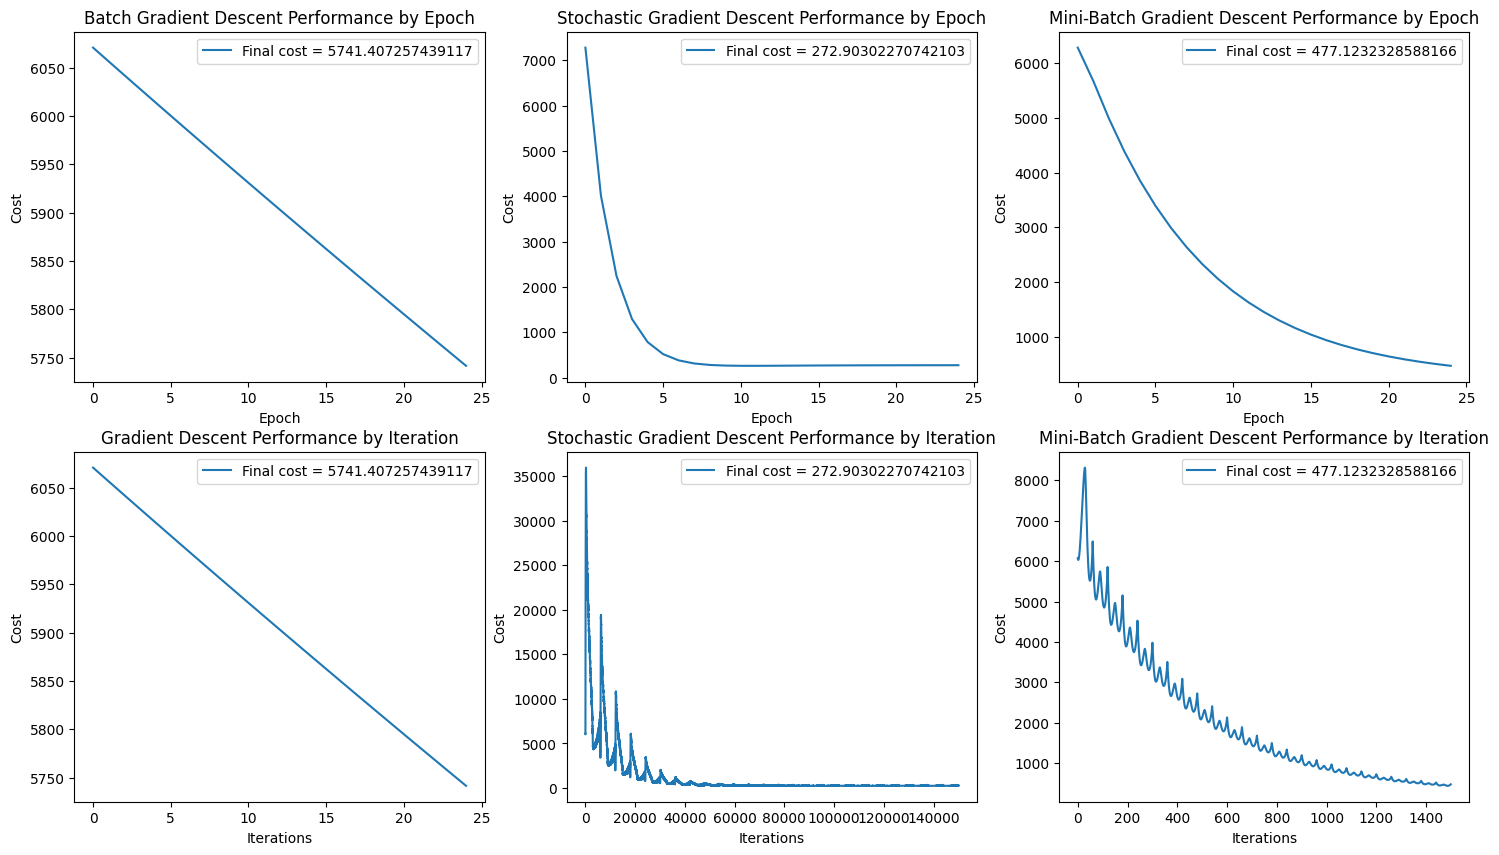

In [9]:
plt.figure(figsize=(18, 10))
# plt.title("Comparison of Update Frequencies")

# Tip: Show the y axis in log scale to better see the differences between methods.
rows = 2
cols = 3
plt.subplot(rows, cols, 1)
plt.title("Batch Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_gd, label=f"Final cost = {J_gd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 2)
plt.title("Stochastic Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_epoch_sgd, label=f"Final cost = {J_epoch_sgd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 3)
plt.title("Mini-Batch Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_epoch_mbgd, label=f"Final cost = {J_epoch_mbgd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 4)
plt.title("Gradient Descent Performance by Iteration")
plt.plot(range(epochs), J_gd, label=f"Final cost = {J_gd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 5)
plt.title("Stochastic Gradient Descent Performance by Iteration")
plt.plot(range(len(J_iters_sgd)), J_iters_sgd, label=f"Final cost = {J_iters_sgd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 6)
plt.title("Mini-Batch Gradient Descent Performance by Iteration")
plt.plot(range(len(J_iters_mbgd)), J_iters_mbgd, label=f"Final cost = {J_iters_mbgd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.show()

### Q1
⭕️⭕️ How did you decide the number of iterations/epochs to run for each method?

I picked a number that balanced cost reduction with time spent training.
Training all three models for 25 epochs took 43.8 seconds running on my local
machine. Note, 25 epochs was very insufficient for Batch Gradient Descent. It
was a little overkill for Stochastic Gradient Descent. It was only somewhat
insufficient for Mini-Batch Gradient Descent.

### Task 5. Shuffling Experiment
Now repeat SGD and mini-batch GD **with shuffling each epoch**.

Required:

⭕️⭕️ 1. plot showing SGD cost per iteration (no shuffle vs shuffle)

⭕️⭕️ 2. plot showing mini-batch cost per iteration (no shuffle vs shuffle)


In [10]:
def stochastic_gradient_descent_shuffled(x, y, w_in, b_in, alpha, num_epochs, random_seed=None):
    """SGD: update using one example at a time. Save cost after iterations & epochs
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations (empty if calculate_cost=False)
      J_epoch_history (list): cost values over epochs (empty if calculate_cost=False)
    """
    assert len(x) == len(y)
    m = len(x)
    w, b = w_in, b_in
    J_history = []
    J_epoch_history = []
    for _ in range(num_epochs):
      # shuffle at start of each epoch
      rng = np.random.default_rng(random_seed)
      idx = rng.permutation(m)
      x_shuf=x[idx]
      y_shuf=y[idx]

      # update for each individual point
      for i in range(m):
        cost = compute_cost(x_shuf, y_shuf, w, b)
        J_history.append(cost)
        x_iter = np.array([x_shuf[i]])
        y_iter = np.array([y_shuf[i]])
        dj_dw, dj_db = compute_gradient(x_iter, y_iter, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
      J_epoch_history.append(cost)
    return w, b, J_history, J_epoch_history

def mini_batch_gradient_descent_shuffled(x, y, w_in, b_in, alpha, num_epochs, batch_size, random_seed=None):
    """Mini-batch GD: update using batches. Save cost once per epoch.
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w_in,b_in (scalar): initial values of model parameters
      alpha (float): learning rate
      num_iters (int): number of iterations to run gradient descent
    Returns:
      w (scalar): updated value of parameter w
      b (scalar): updated value of parameter b
      J_history (list): cost values over iterations (empty if calculate_cost=False)
      J_epoch_history (list): cost values over epochs (empty if calculate_cost=False)
    """
    assert len(x) == len(y)
    m = len(x)
    w, b = w_in, b_in
    J_history = []
    J_epoch_history = []
    for _ in range(num_epochs):
      # shuffle at start of each epoch
      rng = np.random.default_rng(random_seed)
      idx = rng.permutation(m)
      x_shuf=x[idx]
      y_shuf=y[idx]

      # update for each mini-batch of points
      for i in range(0, len(x), batch_size):
        cost = compute_cost(x, y, w, b)
        J_history.append(cost)
        x_batch = np.array(x_shuf[i:i+batch_size])
        y_batch = np.array(y_shuf[i:i+batch_size])
        dj_dw, dj_db = compute_gradient(x_batch, y_batch, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
      J_epoch_history.append(cost)
    return w, b, J_history, J_epoch_history


In [11]:
w_sgd_shuf, b_sgd_shuf, J_iters_sgd_shuf, J_epoch_sgd_shuf = stochastic_gradient_descent_shuffled(
  x_train, y_train, w_init, b_init, alpha, epochs)

w_mbgd_shuf, b_mbgd_shuf, J_iters_mbgd_shuf, J_epoch_mbgd_shuf = mini_batch_gradient_descent_shuffled(
  x_train, y_train, w_init, b_init, alpha, epochs, mini_batch_size)

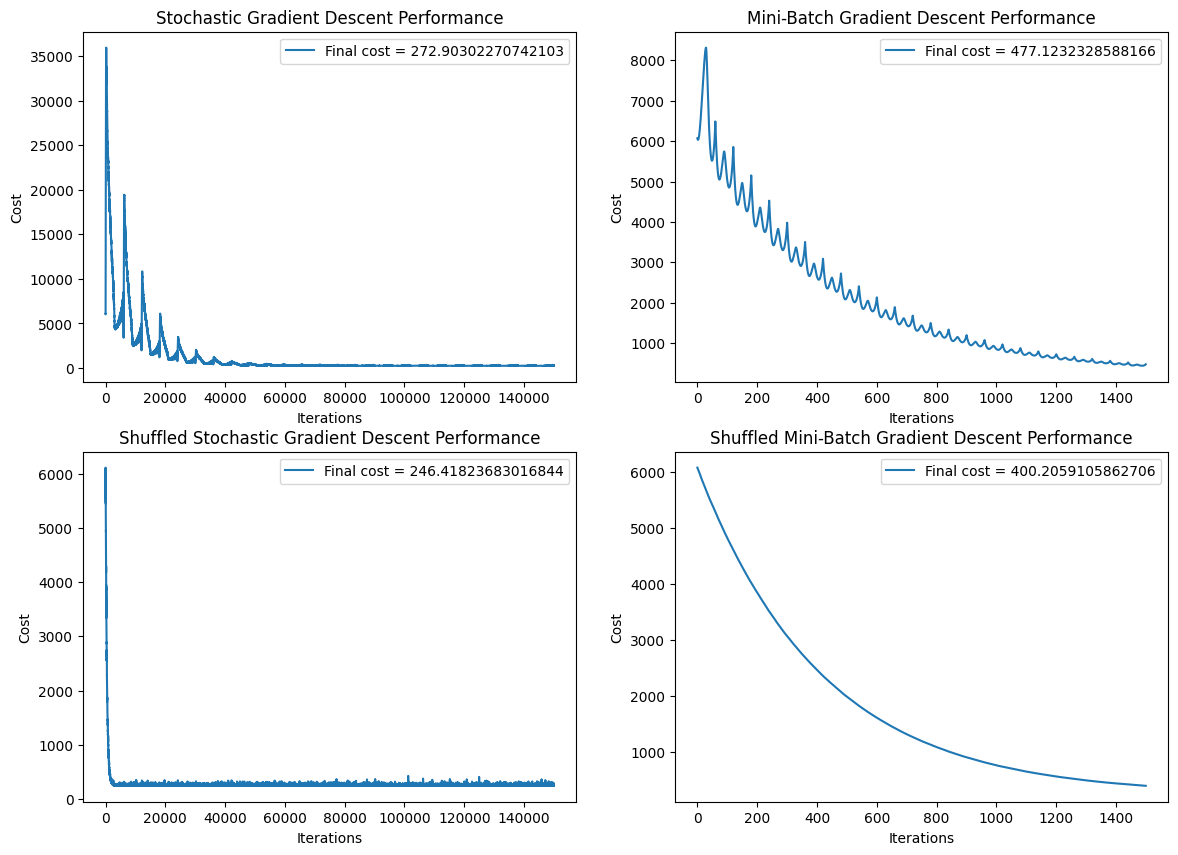

In [ ]:
plt.figure(figsize=(14, 10))

rows = 2
cols = 2
plt.subplot(rows, cols, 1)
plt.title("Stochastic Gradient Descent Performance")
plt.plot(range(len(J_iters_sgd)), J_iters_sgd, label=f'Final cost = {J_iters_sgd[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 2)
plt.title("Mini-Batch Gradient Descent Performance")
plt.plot(range(len(J_iters_mbgd)), J_iters_mbgd, label=f'Final cost = {J_iters_mbgd[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 3)
plt.title("Shuffled Stochastic Gradient Descent Performance")
plt.plot(range(len(J_iters_sgd_shuf)), J_iters_sgd_shuf, label=f'Final cost = {J_iters_sgd_shuf[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 4)
plt.title("Shuffled Mini-Batch Gradient Descent Performance")
plt.plot(range(len(J_iters_mbgd_shuf)), J_iters_mbgd_shuf, label=f'Final cost = {J_iters_mbgd_shuf[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.show()

### Q2

1. Does shuffling change the cost curve? Why or why not?
2. What else you observe when you shuffled the data?

⭕️⭕️


1. Shuffling drastically changes the cost curve because it removes biases from
   the order of the data. In the above (unshuffled) cost curves, there are
   spikes at regular intervals. These are smoothed out when shuffling.
2. The stochastic gradient descent curve drops much more quickly, and the
   mini-batch gradient descent curve follows a much smoother path. I assume this
   is because the mini-batches contain more generalized samples of the data
   rather than clusters.


### Task 6 - Comparison plots
Choose the best and worst method for this dataset out of all the options you tried.

Plot:

⭕️⭕️ 1. cost vs iteration (or epoch) for both methods (clearly labeled)

⭕️⭕️ 2. the training data & the final trained lines for both methods (clearly labeled)

Include your final values of $w$ and $b$ in the legend for each method for plot 1.



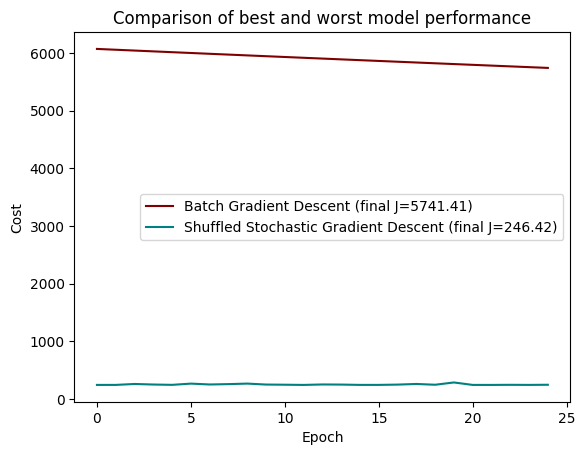

In [13]:
plt.title("Comparison of best and worst model performance")
plt.plot(range(epochs), J_gd, label=f"Batch Gradient Descent (final J={J_gd[-1]:.2f})", color="maroon")
plt.plot(range(epochs), J_epoch_sgd_shuf, label=f"Shuffled Stochastic Gradient Descent (final J={J_epoch_sgd_shuf[-1]:.2f})", color="teal")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.show()


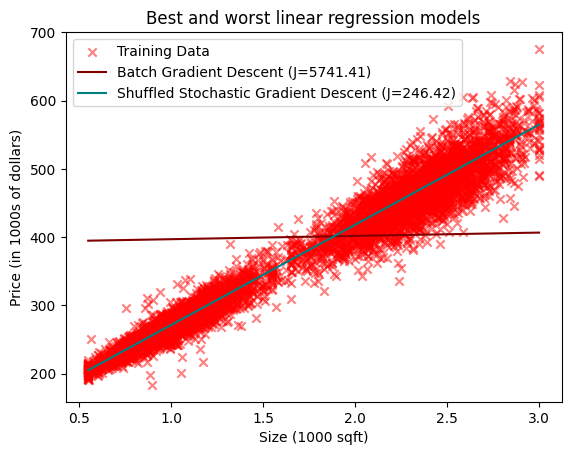

In [16]:
plt.title("Best and worst linear regression models")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.scatter(x_train, y_train, marker='x', c='r', alpha=0.5, label="Training Data")
plt.plot(x_train, compute_model_output(x_train, w_gd, b_gd), c="maroon", label=f"Batch Gradient Descent (J={J_gd[-1]:.2f})")
plt.plot(x_train, compute_model_output(x_train, w_sgd_shuf, b_sgd_shuf), c="teal", label=f"Shuffled Stochastic Gradient Descent (J={J_epoch_sgd_shuf[-1]:.2f})")
plt.legend()
plt.show()


### Q3
1. What does **one iteration** mean in batch gradient descent vs in stochastic gradient descent?
2. Why is the SGD cost curve usually noisier?
3. Did you notice any difference in convergence speed among the three methods? Why or why not?

⭕️⭕️⭕️



1. A single iteration refers to one update of $w$ and $b$. In **batch gradient 
   descent**, one iteration happens every epoch. That is, it calculates the
   gradient using the entire dataset and updates once accordingly.
   Each epoch consists of one iteration. In **stochastic gradient descent**, one
   iteration happens for each point in the dataset. That is, it calculates the
   gradient using a single point and updates accordingly, eventually covering
   the entire dataset. Each epoch consists of $m$ iterations, where $m$ is the
   size of the dataset.
2. The SGD cost curve is usually noisier because it updates from single points,
   so it is sensitive to outliers.
3. I noticed that SGD curve converged the quickest. I think this is because it
   makes the most updates. The BGD curve was the slowest because it makes the
   fewest updates, and the mini-batch curve was in the middle because it made
   more updates than BGD but fewer than SGD.

## Task 7 - Dataset Size Matters

Repeat your previous experiments with a smaller subset of the data.

You can select a random subset of the data from the dataframe like this:

```python
# Select a random subset of 100 examples
subset_df = df.sample(n=100, random_state=42)
x_sub_train = subset_df['Size_1000sqft'].to_numpy()
y_sub_train = subset_df['Price_1000s'].to_numpy()
```
### Q4
⭕️⭕️ 1. Is your chosen method from Task 6 still the best method for the smaller dataset? Why or why not?

⭕️⭕️ Show a plot that justifies your answer for Q4

Stochastic gradient descent is still the best method for the smaller dataset.
However, it matters much less whether I shuffle it or not. In this case,
shuffling did not improve the model performance (actually - it made it
marginally worse). See the plots below.

In [19]:
# Select a random subset of 100 examples
subset_df = df.sample(n=100, random_state=42)
x_sub_train = subset_df['Size_1000sqft'].to_numpy()
y_sub_train = subset_df['Price_1000s'].to_numpy()

In [22]:
w_init = 0
b_init = 400
alpha = 0.01

epochs = 25
mini_batch_size = 10

w_gd, b_gd, J_gd = batch_gradient_descent(
  x_sub_train, y_sub_train, w_init, b_init, alpha, epochs)

w_sgd, b_sgd, J_iters_sgd, J_epoch_sgd = stochastic_gradient_descent(
  x_sub_train, y_sub_train, w_init, b_init, alpha, epochs)

w_mbgd, b_mbgd, J_iters_mbgd, J_epoch_mbgd = mini_batch_gradient_descent(
  x_sub_train, y_sub_train, w_init, b_init, alpha, epochs, mini_batch_size)

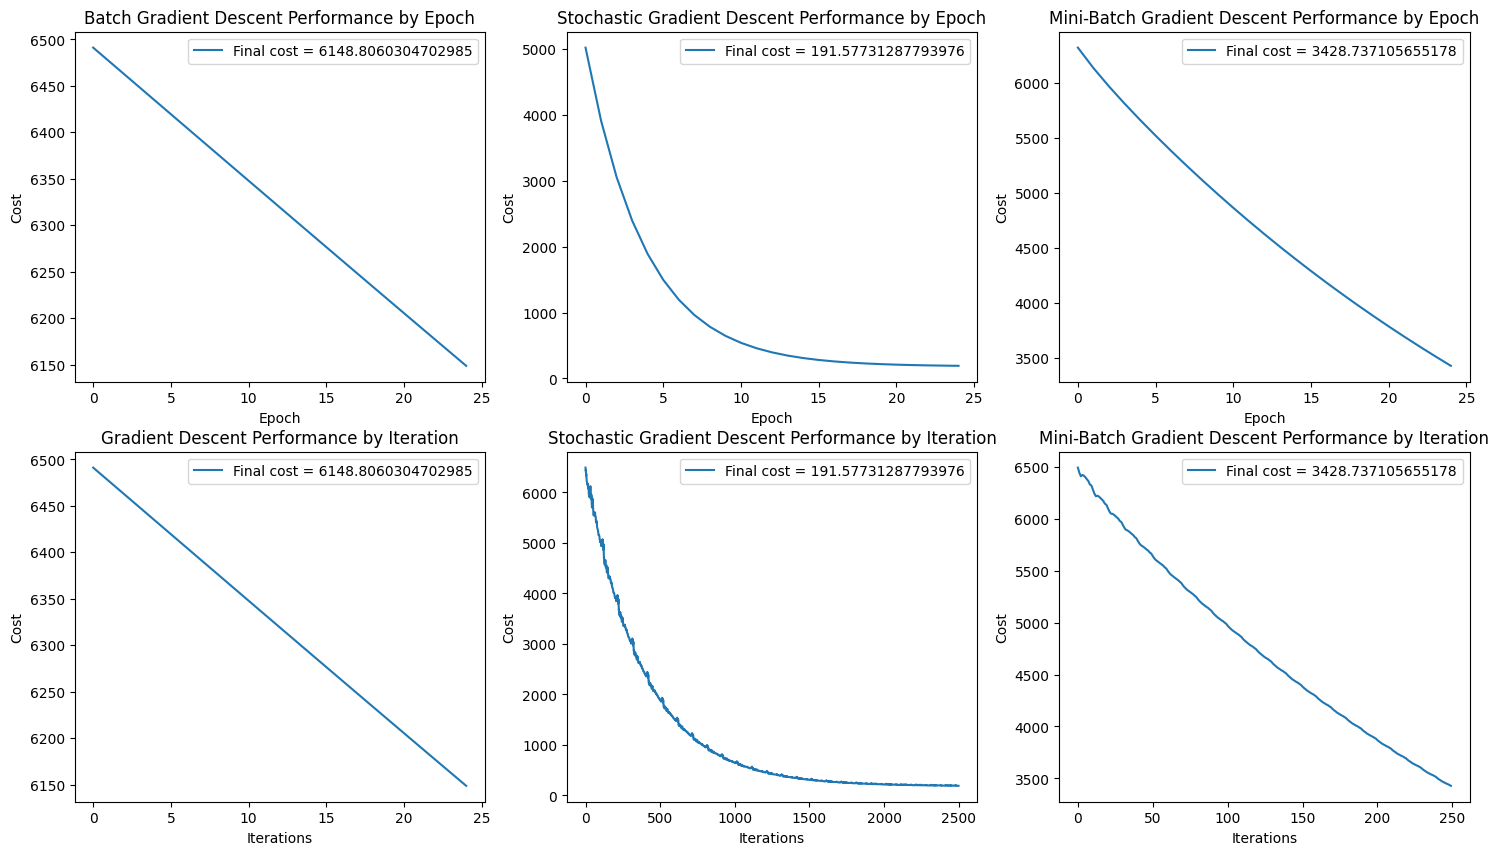

In [23]:
plt.figure(figsize=(18, 10))
# plt.title("Comparison of Update Frequencies")

# Tip: Show the y axis in log scale to better see the differences between methods.
rows = 2
cols = 3
plt.subplot(rows, cols, 1)
plt.title("Batch Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_gd, label=f"Final cost = {J_gd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 2)
plt.title("Stochastic Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_epoch_sgd, label=f"Final cost = {J_epoch_sgd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 3)
plt.title("Mini-Batch Gradient Descent Performance by Epoch")
plt.plot(range(epochs), J_epoch_mbgd, label=f"Final cost = {J_epoch_mbgd[-1]}")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 4)
plt.title("Gradient Descent Performance by Iteration")
plt.plot(range(epochs), J_gd, label=f"Final cost = {J_gd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 5)
plt.title("Stochastic Gradient Descent Performance by Iteration")
plt.plot(range(len(J_iters_sgd)), J_iters_sgd, label=f"Final cost = {J_iters_sgd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 6)
plt.title("Mini-Batch Gradient Descent Performance by Iteration")
plt.plot(range(len(J_iters_mbgd)), J_iters_mbgd, label=f"Final cost = {J_iters_mbgd[-1]}")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.show()

In [24]:
w_sgd_shuf, b_sgd_shuf, J_iters_sgd_shuf, J_epoch_sgd_shuf = stochastic_gradient_descent_shuffled(
  x_sub_train, y_sub_train, w_init, b_init, alpha, epochs)

w_mbgd_shuf, b_mbgd_shuf, J_iters_mbgd_shuf, J_epoch_mbgd_shuf = mini_batch_gradient_descent_shuffled(
  x_sub_train, y_sub_train, w_init, b_init, alpha, epochs, mini_batch_size)

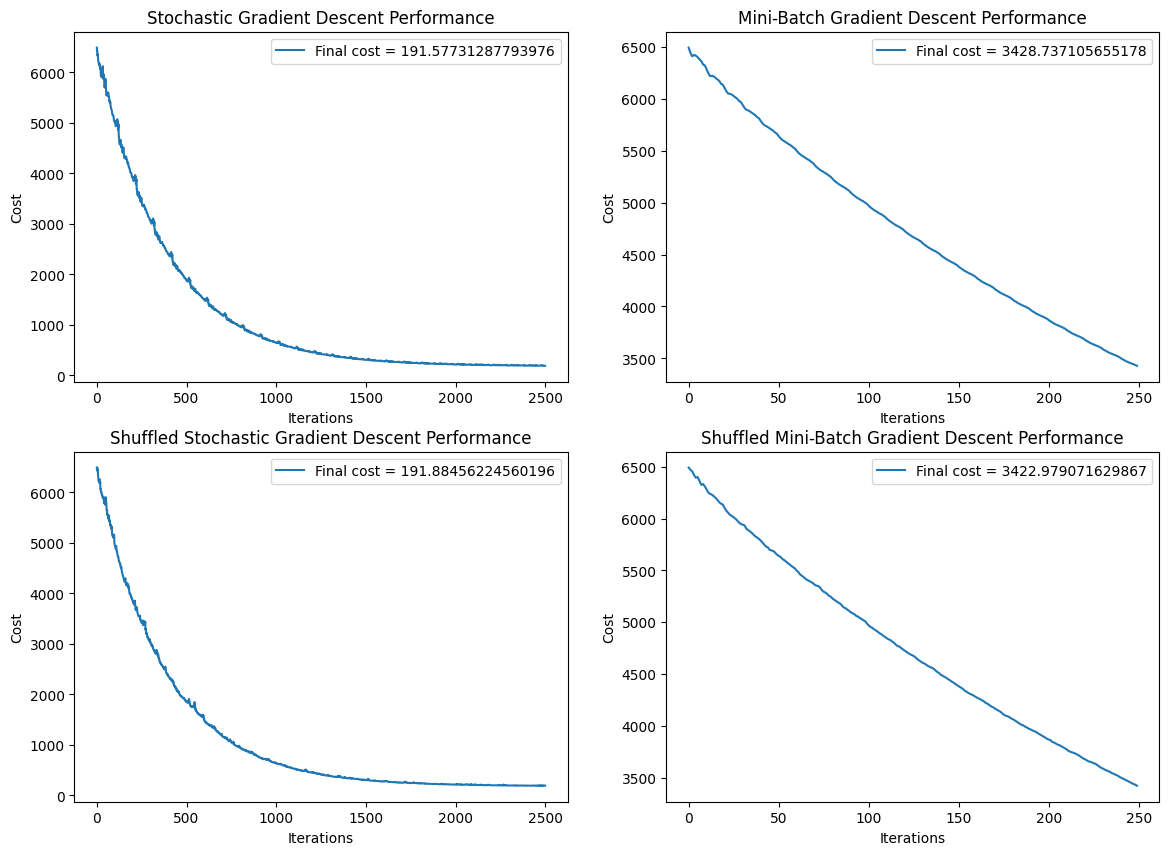

In [25]:
plt.figure(figsize=(14, 10))

rows = 2
cols = 2
plt.subplot(rows, cols, 1)
plt.title("Stochastic Gradient Descent Performance")
plt.plot(range(len(J_iters_sgd)), J_iters_sgd, label=f'Final cost = {J_iters_sgd[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 2)
plt.title("Mini-Batch Gradient Descent Performance")
plt.plot(range(len(J_iters_mbgd)), J_iters_mbgd, label=f'Final cost = {J_iters_mbgd[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 3)
plt.title("Shuffled Stochastic Gradient Descent Performance")
plt.plot(range(len(J_iters_sgd_shuf)), J_iters_sgd_shuf, label=f'Final cost = {J_iters_sgd_shuf[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.subplot(rows, cols, 4)
plt.title("Shuffled Mini-Batch Gradient Descent Performance")
plt.plot(range(len(J_iters_mbgd_shuf)), J_iters_mbgd_shuf, label=f'Final cost = {J_iters_mbgd_shuf[-1]}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()

plt.show()

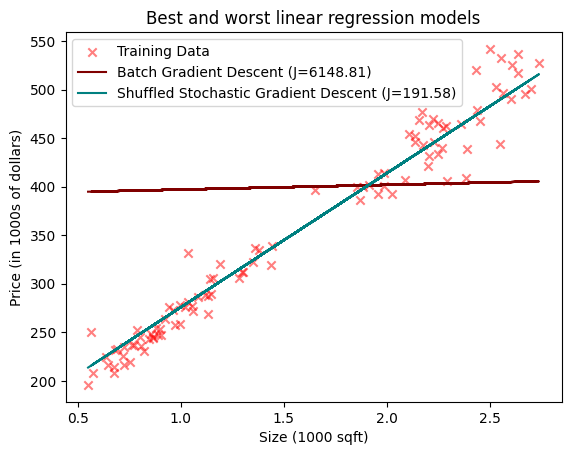

In [28]:
plt.title("Best and worst linear regression models")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.scatter(x_sub_train, y_sub_train, marker='x', c='r', alpha=0.5, label="Training Data")
plt.plot(x_sub_train, compute_model_output(x_sub_train, w_gd, b_gd), c="maroon", label=f"Batch Gradient Descent (J={J_gd[-1]:.2f})")
plt.plot(x_sub_train, compute_model_output(x_sub_train, w_sgd, b_sgd), c="teal", label=f"Shuffled Stochastic Gradient Descent (J={J_epoch_sgd[-1]:.2f})")
plt.legend()
plt.show()
